In [76]:
!pip install catboost

#1. Import các thư viện cần thiết

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Sklearn
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.model_selection   import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics           import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection        import permutation_importance
import joblib

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)

#2. Load dữ liệu (sau preprocessing + train/test split)

In [78]:
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_val.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_val.csv').squeeze()

print('Shape X_train :', X_train.shape)
print('Shape X_test  :', X_test.shape)

Shape X_train : (112560, 18)
Shape X_test  : (28140, 18)


In [79]:
X_train

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,292,0,-1.242616,53,0,71,3.194278,0.000638,-3.301563,5.0,3.0,10,22,117,1,0.453425,1.422613,0
1,135,0,-1.646361,21,0,71,-0.045698,0.000638,0.798772,4.0,3.0,5,32,66,0,-1.622555,-1.407027,1
2,355,1,-1.323365,115,0,71,-0.045698,0.000638,-2.674273,2.0,3.0,11,11,30,0,-0.844062,-1.407027,1
3,209,0,-0.192879,53,1,19,-0.045698,-1.588437,0.033784,3.0,3.0,10,22,106,0,0.972421,-0.699617,1
4,504,0,-1.323365,6,0,71,1.574290,0.000638,0.446877,4.0,3.0,11,11,26,1,0.972421,0.007793,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112555,434,1,1.583599,79,1,71,-0.045698,0.000638,0.033784,3.0,2.0,7,32,26,0,-1.622555,-0.699617,1
112556,17,0,1.260603,119,1,71,-0.045698,-0.793900,0.033784,3.0,3.0,11,22,66,0,0.972421,0.007793,1
112557,150,0,1.583599,71,1,71,-0.045698,0.000638,0.033784,3.0,3.0,10,32,116,1,0.712923,-1.407027,1
112558,505,0,-1.565612,79,0,71,3.194278,0.000638,-3.056767,1.0,3.0,7,22,26,1,-0.584565,0.715203,1


#3. Feature Engineering

> Tạo thêm đặc trưng tổng hợp và tương tác để cải thiện khả năng phân biệt nhãn (Depression).

### 3.1 Tạo Đặc Trưng Tổng Hợp (Aggregate Features)

Các nghiên cứu tâm lý học cho thấy **stress từ nhiều nguồn khác nhau có hiệu ứng cộng dồn** lên nguy cơ trầm cảm.
Ta tạo chỉ số tổng hợp:

$$\text{Stress_Index} = \frac{\text{Academic_Pressure} + \text{Work_Pressure} + \text{Financial_Stress}}{3}$$

Tương tự, **lối sống lành mạnh** (ngủ đủ giấc, thói quen ăn uống, giờ làm vừa phải) được kết hợp thành:

$$\text{Lifestyle_Score} = \text{Sleep_Duration} - \text{Work_Study_Hours}$$

Giá trị càng cao → cân bằng sống/làm việc tốt hơn.

In [80]:
def add_aggregate_features(df):
    """Tạo các đặc trưng tổng hợp từ nhiều cột liên quan."""
    df = df.copy()

    # Chỉ số stress tổng hợp (trung bình 3 nguồn stress)
    stress_cols = ['Academic Pressure', 'Work Pressure', 'Financial Stress']
    df['Stress_Index'] = df[stress_cols].mean(axis=1)

    # Cân bằng ngủ/làm việc: Sleep – WorkHours (cả hai đã được scale)
    df['Lifestyle_Score'] = df['Sleep Duration'] - df['Work/Study Hours']

    # Mức độ hài lòng tổng thể (học tập + công việc)
    df['Overall_Satisfaction'] = df[['Study Satisfaction', 'Job Satisfaction']].mean(axis=1)

    return df

X_train = add_aggregate_features(X_train)
X_test  = add_aggregate_features(X_test)

print(X_train[['Stress_Index','Lifestyle_Score','Overall_Satisfaction']].describe().round(3))

       Stress_Index  Lifestyle_Score  Overall_Satisfaction
count    112560.000       112560.000            112560.000
mean          0.000            8.302                 2.984
std           0.595            2.547                 0.703
min          -1.564           -0.491                 2.000
25%          -0.484            6.028                 2.500
50%          -0.012            8.623                 3.000
75%           0.459           10.547                 3.500
max           1.539           12.623                 4.000


### 3.2 Tạo Đặc Trưng Tương Tác (Interaction Features)

Nhiều nghiên cứu xác nhận rằng **stress cao kết hợp với thiếu ngủ** có tác động gây trầm cảm **mạnh hơn** tổng của từng yếu tố riêng lẻ — đây là **hiệu ứng tương tác phi tuyến** mà các mô hình tuyến tính khó nắm bắt:

$$\text{High_Stress_Low_Sleep} = \mathbb{1}[\text{Stress_Index} > \mu_{\text{stress}}] \times \mathbb{1}[\text{Sleep_Duration} < \mu_{\text{sleep}}]$$

Ngoài ra, **social isolation** được định nghĩa khi người dùng vừa có áp lực cao vừa có sự hài lòng thấp:

$$\text{Isolation_Flag} = \mathbb{1}[\text{Stress_Index} > Q_{75}] \times \mathbb{1}[\text{Overall_Satisfaction} < Q_{25}]$$

In [81]:
def add_interaction_features(df, ref_df=None):
    """
    Tạo interaction features dựa trên ngưỡng từ tập train.
    ref_df: dùng để tính ngưỡng (chỉ dùng X_train, tránh data leakage).
    """
    df = df.copy()
    src = ref_df if ref_df is not None else df

    # Ngưỡng từ training set
    stress_mean = src['Stress_Index'].mean()
    sleep_mean  = src['Sleep Duration'].mean()
    stress_q75  = src['Stress_Index'].quantile(0.75)
    sat_q25     = src['Overall_Satisfaction'].quantile(0.25)

    # Feature 1: Stress cao & Ngủ ít
    df['High_Stress_Low_Sleep'] = (
        (df['Stress_Index']  > stress_mean) &
        (df['Sleep Duration'] < sleep_mean)
    ).astype(int)

    # Feature 2: Isolation flag – stress rất cao & hài lòng thấp
    df['Isolation_Flag'] = (
        (df['Stress_Index']         > stress_q75) &
        (df['Overall_Satisfaction'] < sat_q25)
    ).astype(int)

    # Feature 3: Suicidal thoughts × Stress (product interaction)
    df['Suicidal_x_Stress'] = (
        df['Have you ever had suicidal thoughts ?'] * df['Stress_Index']
    )

    return df

X_train = add_interaction_features(X_train, ref_df=X_train)
X_test  = add_interaction_features(X_test,  ref_df=X_train)  # dùng ngưỡng train

print('High_Stress_Low_Sleep:', X_train['High_Stress_Low_Sleep'].value_counts().to_dict())
print('Isolation_Flag:       ', X_train['Isolation_Flag'].value_counts().to_dict())

High_Stress_Low_Sleep: {0: 85622, 1: 26938}
Isolation_Flag:        {0: 106457, 1: 6103}


In [82]:
X_train

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,...,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Stress_Index,Lifestyle_Score,Overall_Satisfaction,High_Stress_Low_Sleep,Isolation_Flag,Suicidal_x_Stress
0,292,0,-1.242616,53,0,71,3.194278,0.000638,-3.301563,5.0,...,1,0.453425,1.422613,0,1.539176,9.546575,4.0,0,0,1.539176
1,135,0,-1.646361,21,0,71,-0.045698,0.000638,0.798772,4.0,...,0,-1.622555,-1.407027,1,-0.484029,6.622555,3.5,0,0,-0.000000
2,355,1,-1.323365,115,0,71,-0.045698,0.000638,-2.674273,2.0,...,0,-0.844062,-1.407027,1,-0.484029,11.844062,2.5,0,0,-0.000000
3,209,0,-0.192879,53,1,19,-0.045698,-1.588437,0.033784,3.0,...,0,0.972421,-0.699617,1,-0.777917,9.027579,3.0,0,0,-0.000000
4,504,0,-1.323365,6,0,71,1.574290,0.000638,0.446877,4.0,...,1,0.972421,0.007793,1,0.527574,10.027579,3.5,0,0,0.527574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112555,434,1,1.583599,79,1,71,-0.045698,0.000638,0.033784,3.0,...,0,-1.622555,-0.699617,1,-0.248226,8.622555,2.5,0,0,-0.000000
112556,17,0,1.260603,119,1,71,-0.045698,-0.793900,0.033784,3.0,...,0,0.972421,0.007793,1,-0.277268,10.027579,3.0,0,0,-0.000000
112557,150,0,1.583599,71,1,71,-0.045698,0.000638,0.033784,3.0,...,1,0.712923,-1.407027,1,-0.484029,9.287077,3.0,0,0,-0.484029
112558,505,0,-1.565612,79,0,71,3.194278,0.000638,-3.056767,1.0,...,1,-0.584565,0.715203,1,1.303373,7.584565,2.0,1,1,1.303373


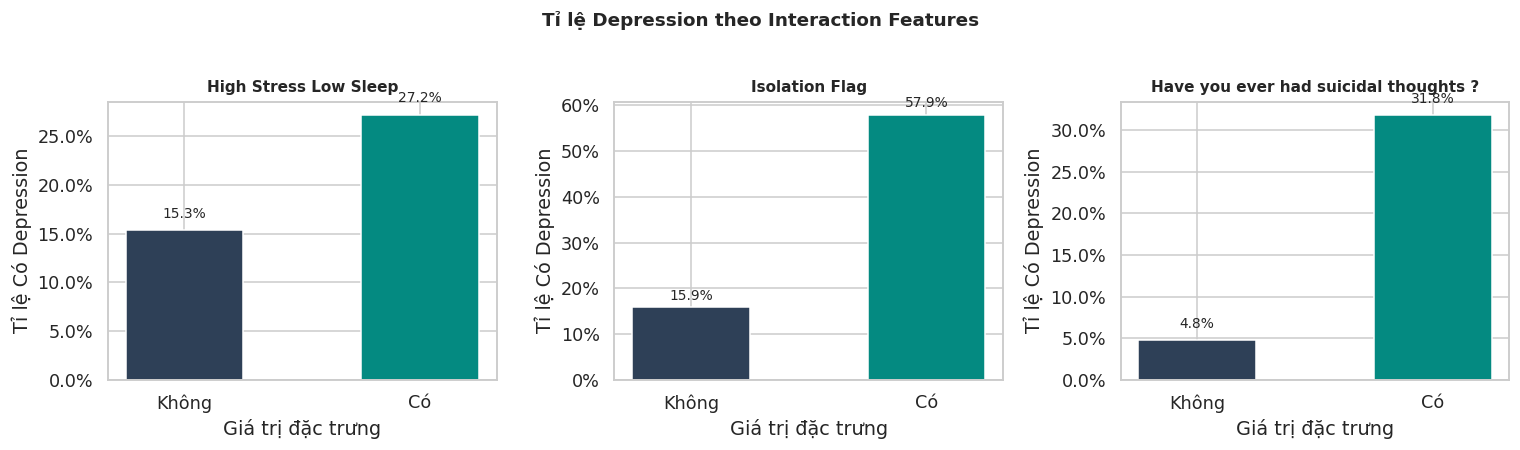

In [83]:
# ── Visualize: tỉ lệ Depression theo interaction features ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

flag_features = ['High_Stress_Low_Sleep', 'Isolation_Flag',
                 'Have you ever had suicidal thoughts ?']
labels_map = {0: 'Không', 1: 'Có'}

for ax, feat in zip(axes, flag_features):
    tmp = pd.DataFrame({'feature': X_train[feat], 'Depression': y_train.squeeze()})
    rate = tmp.groupby('feature')['Depression'].mean().rename(labels_map)
    bars = ax.bar(rate.index, rate.values * 100,
                  color=['#2E4057','#048A81'], edgecolor='white', width=0.5)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(feat.replace('_',' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('Giá trị đặc trưng')
    ax.set_ylabel('Tỉ lệ Có Depression')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Tỉ lệ Depression theo Interaction Features', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Chọn Lọc Đặc Trưng (Feature Selection)

Sau khi tạo thêm 6 features mới, ta cần kiểm tra tất cả features và loại bỏ những features nhiễu hoặc dư thừa. Hai phương pháp được dùng:

**① Mutual Information (MI)**

MI đo lường mức độ phụ thuộc giữa feature $X_i$ và nhãn $Y$:

$$I(X_i; Y) = \sum_{x \in X_i} \sum_{y \in Y} p(x, y) \log\frac{p(x,y)}{p(x)\,p(y)}$$

- $I = 0$: $X_i$ hoàn toàn độc lập với $Y$ → nên loại bỏ
- $I > 0$: $X_i$ mang thông tin về $Y$ → nên giữ lại

**② Tree-based Permutation Importance**

Huấn luyện một Random Forest nhỏ, sau đó đo mức độ giảm accuracy khi **xáo trộn ngẫu nhiên** từng cột:

$$\text{Importance}(X_i) = \text{score}(\text{original}) - \mathbb{E}[\text{score}(X_i \text{ permuted})]$$

In [84]:
# ── Mutual Information ──────────────────────────────────────────────────

# Loại cột Name (ID) nếu còn
drop_cols = [c for c in ['Name'] if c in X_train.columns]
X_tr = X_train.drop(columns=drop_cols)
X_te = X_test.drop(columns=drop_cols)

mi_scores = mutual_info_classif(X_tr, y_train, random_state=SEED)
mi_df = pd.DataFrame({'Feature': X_tr.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False).reset_index(drop=True)

print('Mutual Information Score (top 20):')
print(mi_df.head(20).to_string(index=False))

Mutual Information Score (top 20):
                              Feature  MI_Score
                                  Age  0.198590
                    Suicidal_x_Stress  0.170959
                         Stress_Index  0.151065
      Working Professional or Student  0.133323
                                 CGPA  0.112913
                   Study Satisfaction  0.102892
                    Academic Pressure  0.096755
Have you ever had suicidal thoughts ?  0.076816
                           Profession  0.076360
                        Work Pressure  0.073540
                     Job Satisfaction  0.069056
                               Degree  0.039189
                     Financial Stress  0.030105
                      Lifestyle_Score  0.026857
                       Isolation_Flag  0.024535
                     Work/Study Hours  0.024524
                       Dietary Habits  0.018549
                               Gender  0.013222
                 Overall_Satisfaction  0.012914
     

In [85]:
# ── Tree-based Permutation Importance ────────────────────────────────
rf_selector = RandomForestClassifier(n_estimators=100, max_depth=8,
                                     random_state=SEED, n_jobs=-1)
rf_selector.fit(X_tr, y_train)

perm_imp = permutation_importance(rf_selector, X_tr, y_train,
                                  n_repeats=10, random_state=SEED, n_jobs=-1)
perm_df = pd.DataFrame({
    'Feature'   : X_tr.columns,
    'Perm_Mean' : perm_imp.importances_mean,
    'Perm_Std'  : perm_imp.importances_std
}).sort_values('Perm_Mean', ascending=False).reset_index(drop=True)

print('Permutation Importance (top 20):')
print(perm_df.head(20).to_string(index=False))

Permutation Importance (top 20):
                              Feature  Perm_Mean  Perm_Std
                                  Age   0.048053  0.000609
Have you ever had suicidal thoughts ?   0.017063  0.000453
                    Suicidal_x_Stress   0.011774  0.000300
      Working Professional or Student   0.009413  0.000188
                         Stress_Index   0.005466  0.000182
                     Job Satisfaction   0.003210  0.000223
                     Work/Study Hours   0.002958  0.000226
                     Financial Stress   0.001873  0.000137
                       Dietary Habits   0.001854  0.000147
                    Academic Pressure   0.001842  0.000078
                 Overall_Satisfaction   0.001315  0.000161
                       Isolation_Flag   0.001093  0.000090
                        Work Pressure   0.000982  0.000224
                      Lifestyle_Score   0.000860  0.000146
                               Degree   0.000845  0.000093
                       

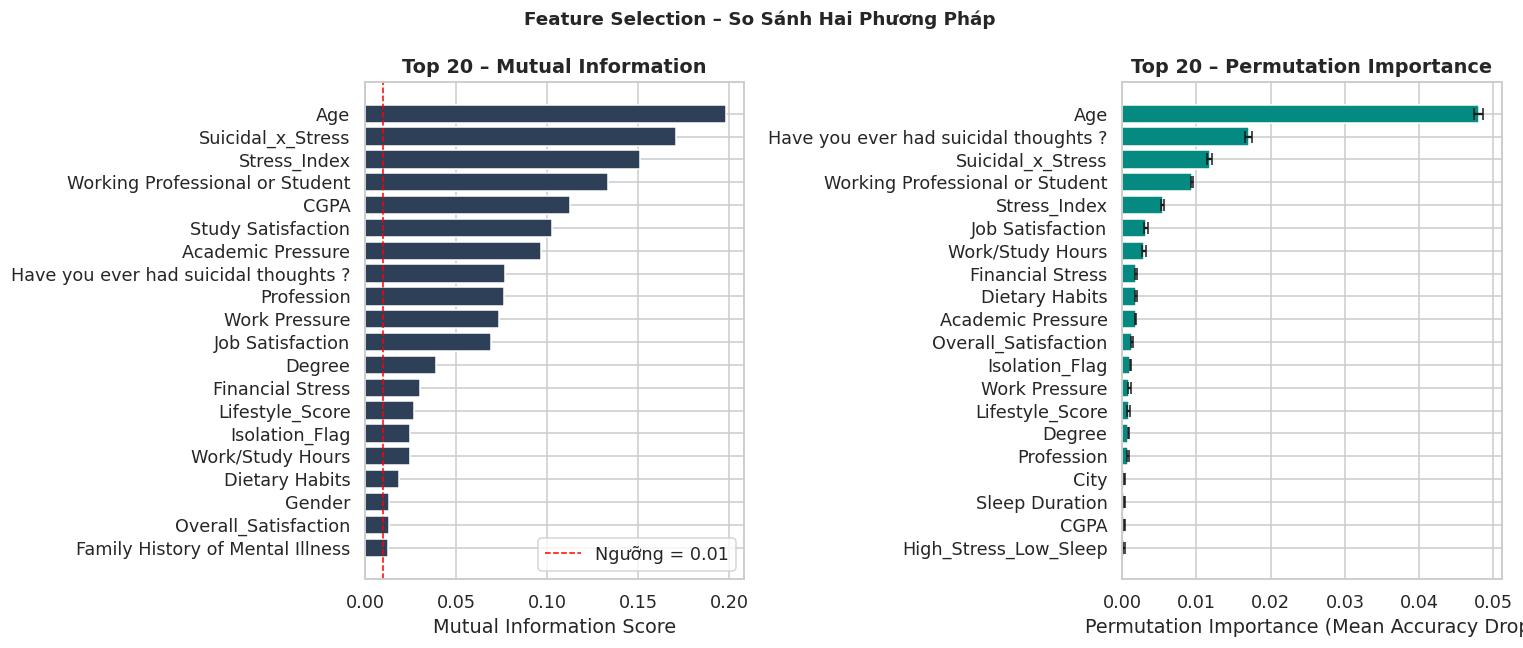

In [86]:
# ── Visualize cả hai phương pháp ────────────────────────────────────────────
TOP_N = 20
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# MI
mi_top = mi_df.head(TOP_N)
ax1.barh(mi_top['Feature'][::-1], mi_top['MI_Score'][::-1],
         color='#2E4057', edgecolor='white')
ax1.set_xlabel('Mutual Information Score')
ax1.set_title(f'Top {TOP_N} – Mutual Information', fontweight='bold')
ax1.axvline(x=0.01, color='red', linestyle='--', linewidth=1, label='Ngưỡng = 0.01')
ax1.legend()

# Permutation
perm_top = perm_df.head(TOP_N)
ax2.barh(perm_top['Feature'][::-1], perm_top['Perm_Mean'][::-1],
         xerr=perm_top['Perm_Std'][::-1],
         color='#048A81', edgecolor='white', capsize=4)
ax2.set_xlabel('Permutation Importance (Mean Accuracy Drop)')
ax2.set_title(f'Top {TOP_N} – Permutation Importance', fontweight='bold')

plt.suptitle('Feature Selection – So Sánh Hai Phương Pháp', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [87]:
# ── Chọn features: union của top-k từ 2 phương pháp ──────────────────────
mi_top   = set(mi_df.head(20)['Feature'])        # nới rộng top
perm_top = set(perm_df.head(20)['Feature'])

SELECTED_FEATURES = sorted(mi_top | perm_top)


# ── Loại feature thật sự yếu (cả 2 đều thấp) ─────────────────────────────
mi_weak   = set(mi_df[mi_df['MI_Score'] < 0.005]['Feature'])
perm_weak = set(perm_df[perm_df['Perm_Mean'] < 0.001]['Feature'])

weak = mi_weak & perm_weak   # chỉ remove nếu cả 2 cùng chê

SELECTED_FEATURES = [f for f in SELECTED_FEATURES if f not in weak]


# ── Log ─────────────────────────────────────────────────────────────────
print(f'Số features được chọn: {len(SELECTED_FEATURES)}')
print('📋 Danh sách features:')
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f'   {i:2d}. {f}')


# ── Apply ───────────────────────────────────────────────────────────────
X_train_sel = X_tr[SELECTED_FEATURES]
X_test_sel  = X_te[SELECTED_FEATURES]

print(f'\nShape sau khi chọn lọc: X_train={X_train_sel.shape}, X_test={X_test_sel.shape}')

Số features được chọn: 22
📋 Danh sách features:
    1. Academic Pressure
    2. Age
    3. CGPA
    4. Degree
    5. Dietary Habits
    6. Family History of Mental Illness
    7. Financial Stress
    8. Gender
    9. Have you ever had suicidal thoughts ?
   10. High_Stress_Low_Sleep
   11. Isolation_Flag
   12. Job Satisfaction
   13. Lifestyle_Score
   14. Overall_Satisfaction
   15. Profession
   16. Sleep Duration
   17. Stress_Index
   18. Study Satisfaction
   19. Suicidal_x_Stress
   20. Work Pressure
   21. Work/Study Hours
   22. Working Professional or Student

Shape sau khi chọn lọc: X_train=(112560, 22), X_test=(28140, 22)


---
# 4. Xử Lý Class Imbalance

Với tỉ lệ nhãn **80% – 20%**, ba kỹ thuật sẽ được áp dụng và so sánh:

| Kỹ thuật | Ý tưởng | Áp dụng tại |
|----------|---------|-------------|
| **SMOTE** | Tạo thêm mẫu tổng hợp cho nhãn 1 | Trước khi train |
| **class_weight / scale_pos_weight** | Tăng penalty khi sai nhãn 1 | Trong model |
| **Threshold Tuning** | Dịch chuyển ngưỡng quyết định 0.5 → tối ưu | Sau khi predict_proba |

### 4.1 SMOTE – Synthetic Minority Oversampling Technique

SMOTE tạo mẫu mới bằng cách nội suy tuyến tính giữa một điểm thiểu số $x_i$ và một trong $k$ láng giềng gần nhất $x_{nn}$:

$$x_{\text{new}} = x_i + \lambda \cdot (x_{nn} - x_i), \quad \lambda \sim \text{Uniform}(0, 1)$$


Trước SMOTE:
  Nhãn 0: 92,106   Nhãn 1: 20,454
Sau SMOTE:
  Nhãn 0: 92,106   Nhãn 1: 46,053


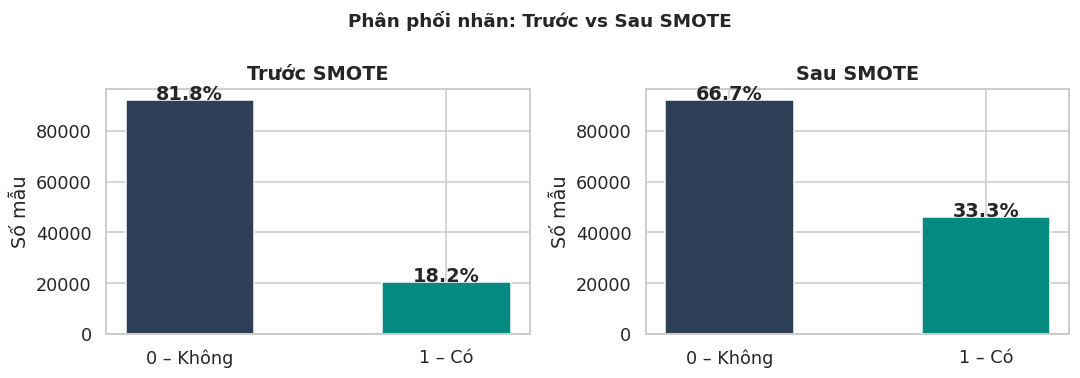

In [88]:
smote = SMOTE(sampling_strategy=0.5,  # nhãn 1 sẽ bằng 50% nhãn 0 sau SMOTE
              k_neighbors=5,
              random_state=SEED)

X_train_smote, y_train_smote = smote.fit_resample(X_train_sel, y_train)

print('Trước SMOTE:')
print(f'  Nhãn 0: {(y_train==0).sum():,}   Nhãn 1: {(y_train==1).sum():,}')
print('Sau SMOTE:')
print(f'  Nhãn 0: {(y_train_smote==0).sum():,}   Nhãn 1: {(y_train_smote==1).sum():,}')

# Visualize trước/sau
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, (yt, title) in zip(axes, [(y_train,'Trước SMOTE'), (y_train_smote,'Sau SMOTE')]):
    vc = yt.value_counts()
    pct = yt.value_counts(normalize=True)*100
    bars = ax.bar(['0 – Không', '1 – Có'], vc.values,
                  color=['#2E4057','#048A81'], edgecolor='white', width=0.5)
    for bar, p in zip(bars, pct.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                f'{p:.1f}%', ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Số mẫu')
plt.suptitle('Phân phối nhãn: Trước vs Sau SMOTE', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.2 class_weight / scale_pos_weight

Thay vì tạo thêm dữ liệu, ta tăng **trọng số penalty** cho nhãn thiểu số trong hàm loss:

$$\mathcal{L}_{\text{weighted}} = -\frac{1}{N}\sum_{i=1}^{N} w_{y_i} \left[y_i \log\hat{p}_i + (1-y_i)\log(1-\hat{p}_i)\right]$$

Với $w_1 = \dfrac{N_0}{N_1}$ (mô hình phạt nặng hơn khi bỏ sót nhãn 1):

$$w_1 = \frac{\text{label 0}}{\text{label 1}} = \frac{80}{20} = 4$$

In [89]:
# ── Tính scale_pos_weight ─────────────────────────────────────────────────
n0 = (y_train == 0).sum()
n1 = (y_train == 1).sum()
SCALE_POS_WEIGHT = n0 / n1

print(f'Nhãn 0: {n0:,}  |  Nhãn 1: {n1:,}')
print(f'scale_pos_weight = {n0}/{n1} = {SCALE_POS_WEIGHT:.3f}')
print(f'→ Mô hình sẽ phạt nặng hơn {SCALE_POS_WEIGHT:.1f}× khi bỏ sót nhãn 1')

Nhãn 0: 92,106  |  Nhãn 1: 20,454
scale_pos_weight = 92106/20454 = 4.503
→ Mô hình sẽ phạt nặng hơn 4.5× khi bỏ sót nhãn 1


### 4.3 Threshold Tuning

Mặc định, mô hình dùng ngưỡng $t = 0.5$:

$$\hat{y} = \begin{cases} 1 & \text{nếu } P(Y=1 \mid x) \geq t \\ 0 & \text{ngược lại} \end{cases}$$

Với dữ liệu mất cân bằng, hạ ngưỡng $t < 0.5$ giúp mô hình **nhạy hơn với nhãn 1** (tăng Recall), đánh đổi một phần Precision. Ngưỡng tối ưu được chọn bằng cách **tối đa hoá F1-score nhãn 1** trên validation set:

$$t^* = \arg\max_{t \in [0,1]} F_1\bigl(y_{\text{val}},\, \hat{y}(t)\bigr)$$

In [90]:
def find_best_threshold(model, X_val, y_val, metric='f1'):
    """
    Tìm ngưỡng tối ưu tối đa hoá F1-score nhãn 1 trên validation set.
    Trả về: (best_threshold, best_score, df_curve)
    """
    probs = model.predict_proba(X_val)[:, 1]
    thresholds = np.arange(0.05, 0.75, 0.01)
    records = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        records.append({
            'threshold' : t,
            'accuracy'  : accuracy_score(y_val, preds),
            'precision' : precision_score(y_val, preds, zero_division=0),
            'recall'    : recall_score(y_val, preds, zero_division=0),
            'f1'        : f1_score(y_val, preds, zero_division=0),
        })
    df = pd.DataFrame(records)
    best_idx = df[metric].idxmax()
    return df.loc[best_idx, 'threshold'], df.loc[best_idx, metric], df

---
# 5. Model Development

Ba mô hình **Gradient Boosting** mạnh nhất trên dữ liệu bảng (tabular data):

| Model | Đặc điểm nổi bật | Xử lý imbalance |
|-------|------------------|-----------------|
| **XGBoost** | Regularization L1/L2, second-order gradient | `scale_pos_weight` |
| **LightGBM** | Histogram splits, leaf-wise growth, rất nhanh | `is_unbalance=True` |
| **CatBoost** | Xử lý categorical tự nhiên, ít overfit | `class_weights` |

Mỗi mô hình được train với **3 chiến lược imbalance** → tổng **9 thực nghiệm**.

In [91]:
# ── Chia validation set từ train để tune threshold ───────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sel, y_train,
    test_size=0.15, stratify=y_train, random_state=SEED
)
# SMOTE chỉ fit trên X_tr (tránh leak sang X_val)
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, y_tr)

print(f'Train split : {X_tr.shape[0]:,} mẫu  |  SMOTE train: {X_tr_smote.shape[0]:,} mẫu')
print(f'Validation  : {X_val.shape[0]:,} mẫu')
print(f'Test        : {X_test.shape[0]:,} mẫu')

Train split : 95,676 mẫu  |  SMOTE train: 117,435 mẫu
Validation  : 16,884 mẫu
Test        : 28,140 mẫu


### 5.1 XGBoost

**XGBoost** là một thuật toán thuộc họ Gradient Boosting, xây dựng mô hình bằng cách thêm dần các cây quyết định để sửa lỗi của các bước trước.

---

### Hàm mục tiêu

Tại bước boosting thứ $t$:

$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^{N} \left[g_i f_t(x_i) + \frac{1}{2}h_i f_t^2(x_i)\right] + \Omega(f_t)
$$

Trong đó:
- $f_t(x_i)$: cây quyết định mới ở bước $t$
- $g_i$: gradient (đạo hàm bậc 1) → hướng và mức độ sai
- $h_i$: hessian (đạo hàm bậc 2) → độ tin cậy của gradient

---

### Regularization

$$
\Omega(f) = \gamma T + \frac{1}{2}\lambda \|w\|^2
$$

- $\gamma T$: phạt số lượng lá → giảm độ phức tạp
- $\lambda \|w\|^2$: phạt trọng số lớn → tránh overfitting

---

### Ý tưởng chính

1. Dự đoán ban đầu  
2. Tính sai số (gradient, hessian)  
3. Xây cây mới để sửa sai  
4. Cộng vào mô hình  
5. Lặp lại nhiều lần  


In [92]:
# ── XGBoost × 3 chiến lược imbalance ─────────────────────────────────────
BASE_XGB = dict(n_estimators=500, learning_rate=0.05, max_depth=6,
                subsample=0.8, colsample_bytree=0.8,
                eval_metric='logloss', early_stopping_rounds=30,
                random_state=SEED, n_jobs=-1, verbosity=0)

# Strategy A – class_weight (scale_pos_weight)
xgb_cw = XGBClassifier(**BASE_XGB, scale_pos_weight=SCALE_POS_WEIGHT)
xgb_cw.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
print(f'XGB class_weight   – best iter: {xgb_cw.best_iteration}')

# Strategy B – SMOTE (không cần scale_pos_weight)
xgb_sm = XGBClassifier(**BASE_XGB)
xgb_sm.fit(X_tr_smote, y_tr_smote, eval_set=[(X_val, y_val)], verbose=False)
print(f'XGB SMOTE          – best iter: {xgb_sm.best_iteration}')

# Strategy C – Threshold tuning (train với class_weight, tune ngưỡng)
xgb_th = XGBClassifier(**BASE_XGB, scale_pos_weight=SCALE_POS_WEIGHT)
xgb_th.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
xgb_th_t, _, _ = find_best_threshold(xgb_th, X_val, y_val, metric='f1')
print(f'XGB Threshold      – best threshold: {xgb_th_t:.2f}')

XGB class_weight   – best iter: 491
XGB SMOTE          – best iter: 324
XGB Threshold      – best threshold: 0.72


### 5.2 LightGBM

**LightGBM** là một thuật toán Gradient Boosting tối ưu cho tốc độ và hiệu năng, đặc biệt hiệu quả với dataset lớn.

---

### Ý tưởng chính

Khác với các thuật toán truyền thống, LightGBM sử dụng:

- **Histogram-based algorithm** (gom dữ liệu vào các bins)
- **Leaf-wise growth** (mở rộng cây theo lá tốt nhất)

Nhờ đó:
- Train nhanh hơn
- Ít tốn bộ nhớ
- Vẫn giữ độ chính xác cao

---

### Histogram-based algorithm

Thay vì xét từng giá trị liên tục, LightGBM:

- Gom các giá trị của feature vào $B$ khoảng (bins)
- Tính toán trên bins thay vì từng điểm dữ liệu


---

### Công thức Gain (đánh giá split)

$$
\text{Gain} = \frac{1}{2}\left[
\frac{G_L^2}{H_L+\lambda} +
\frac{G_R^2}{H_R+\lambda} -
\frac{(G_L+G_R)^2}{H_L+H_R+\lambda}
\right] - \gamma
$$

Trong đó:

- $G_L, G_R$: tổng gradient của nhánh trái/phải  
- $H_L, H_R$: tổng hessian của nhánh trái/phải  
- $\lambda$: hệ số regularization (giảm overfitting)  
- $\gamma$: ngưỡng để split (tránh chia không cần thiết)

---

### Ý nghĩa

- Gain càng lớn → split càng tốt  
- LightGBM chọn split có Gain lớn nhất  
- Giúp mô hình học được cấu trúc dữ liệu hiệu quả hơn  

---

### Ưu điểm

- Rất nhanh với dữ liệu lớn  
- Bộ nhớ thấp  
- Độ chính xác cao  
- Hỗ trợ dữ liệu lớn và nhiều feature  


In [93]:
# ── LightGBM × 3 chiến lược imbalance ────────────────────────────────────
import lightgbm as lgb

BASE_LGB = dict(n_estimators=700, learning_rate=0.03, num_leaves=63,
                min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
                random_state=SEED, n_jobs=-1, verbose=-1)

CB = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]

# Strategy A – is_unbalance
lgb_cw = LGBMClassifier(**BASE_LGB, is_unbalance=True)
lgb_cw.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=CB)
print(f'LGB is_unbalance   – best iter: {lgb_cw.best_iteration_}')

# Strategy B – SMOTE
lgb_sm = LGBMClassifier(**BASE_LGB)
lgb_sm.fit(X_tr_smote, y_tr_smote, eval_set=[(X_val, y_val)], callbacks=CB)
print(f'LGB SMOTE          – best iter: {lgb_sm.best_iteration_}')

# Strategy C – Threshold tuning
lgb_th = LGBMClassifier(**BASE_LGB, is_unbalance=True)
lgb_th.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=CB)
lgb_th_t, _, _ = find_best_threshold(lgb_th, X_val, y_val, metric='f1')
print(f'LGB Threshold      – best threshold: {lgb_th_t:.2f}')

LGB is_unbalance   – best iter: 698
LGB SMOTE          – best iter: 310
LGB Threshold      – best threshold: 0.70


### 5.3 CatBoost

**CatBoost** là một thuật toán Gradient Boosting được thiết kế để xử lý tốt dữ liệu phân loại và giảm overfitting.

---

### Ordered Boosting

CatBoost sử dụng **Ordered Boosting** để tránh *prediction shift*.

Gradient tại điểm $i$:

$$
g_i = -\frac{\partial \ell(y_i,\, F_{i-1}(x_i))}{\partial F_{i-1}(x_i)}
$$

Trong đó:
- $F_{i-1}(x_i)$: dự đoán từ model chỉ học trên $\{x_1, ..., x_{i-1}\}$

Điều này đảm bảo:
- Không dùng thông tin “tương lai”
- Giảm overfitting do target leakage

---

### Xử lý categorical features

CatBoost sử dụng **target statistics**:

$$
\hat{x}_i = \frac{\sum_{j < i} y_j + a \cdot P}{i - 1 + a}
$$

Trong đó:
- $\sum_{j < i} y_j$: tổng target của các mẫu trước đó
- $P$: giá trị prior (trung bình toàn cục)
- $a$: hệ số làm mượt (smoothing)

Ý nghĩa:
- Tránh overfitting khi category có ít dữ liệu
- Không cần One-hot Encoding

---

### Ý tưởng chính

1. Sắp xếp dữ liệu ngẫu nhiên  
2. Tính feature categorical bằng target statistics (không leak)  
3. Tính gradient chỉ dựa trên dữ liệu trước đó  
4. Xây cây để giảm lỗi  
5. Lặp lại  

---

### Ưu điểm

- Xử lý categorical cực tốt  
- Giảm overfitting mạnh  
- Không cần preprocessing phức tạp  

In [94]:
# ── CatBoost × 3 chiến lược imbalance ────────────────────────────────────
BASE_CAT = dict(iterations=500, learning_rate=0.05, depth=6,
                eval_metric='Logloss', early_stopping_rounds=30,
                random_seed=SEED, verbose=0)

# Strategy A – class_weights
cat_cw = CatBoostClassifier(**BASE_CAT,
             class_weights={0: 1.0, 1: SCALE_POS_WEIGHT})
cat_cw.fit(X_tr, y_tr, eval_set=(X_val, y_val))
print(f'CAT class_weight   – best iter: {cat_cw.best_iteration_}')

# Strategy B – SMOTE
cat_sm = CatBoostClassifier(**BASE_CAT)
cat_sm.fit(X_tr_smote, y_tr_smote, eval_set=(X_val, y_val))
print(f'CAT SMOTE          – best iter: {cat_sm.best_iteration_}')

# Strategy C – Threshold tuning
cat_th = CatBoostClassifier(**BASE_CAT,
             class_weights={0: 1.0, 1: SCALE_POS_WEIGHT})
cat_th.fit(X_tr, y_tr, eval_set=(X_val, y_val))
cat_th_t, _, _ = find_best_threshold(cat_th, X_val, y_val, metric='f1')
print(f'CAT Threshold      – best threshold: {cat_th_t:.2f}')

CAT class_weight   – best iter: 365
CAT SMOTE          – best iter: 399
CAT Threshold      – best threshold: 0.74


---
#6. Experiments & Results

### Tại sao không chỉ dùng Accuracy?

Với 80% nhãn 0, một mô hình dự đoán toàn 0 đạt accuracy = 80% nhưng hoàn toàn **bỏ sót 100% ca trầm cảm** (Recall nhãn 1 = 0). Do đó ta ưu tiên:

| Chỉ số | Công thức | Tập trung vào |
|--------|-----------|---------------|
| **Recall (nhãn 1)** | $\frac{TP}{TP+FN}$ | Không bỏ sót ca bệnh |
| **Precision (nhãn 1)** | $\frac{TP}{TP+FP}$ | Không báo động nhầm |
| **F1 (nhãn 1)** | $\frac{2 \cdot P \cdot R}{P+R}$ | Cân bằng cả hai |
| **Accuracy** | $\frac{TP+TN}{N}$ | Metric Kaggle |
| **AUC-ROC** | $\int_0^1 TPR\,d(FPR)$ | Khả năng phân biệt tổng thể |

In [95]:
# ── Hàm đánh giá đầy đủ (hỗ trợ custom threshold) ──────────────────────────
def evaluate(model, X_te, y_te, name, threshold=0.5):
    """Đánh giá model trên test set với threshold tuỳ chỉnh."""
    prob  = model.predict_proba(X_te)[:, 1]
    pred  = (prob >= threshold).astype(int)
    cm    = confusion_matrix(y_te, pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        'Model'          : name,
        'Threshold'      : threshold,
        'Accuracy'       : round(accuracy_score(y_te, pred), 4),
        'AUC-ROC'        : round(roc_auc_score(y_te, prob), 4),
        'F1 (label=1)'   : round(f1_score(y_te, pred, pos_label=1, zero_division=0), 4),
        'Precision (1)'  : round(precision_score(y_te, pred, pos_label=1, zero_division=0), 4),
        'Recall (1)'     : round(recall_score(y_te, pred, pos_label=1, zero_division=0), 4),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
    }

###6.1. Chạy tất cả 9 thực nghiệm + 1 Baseline

In [96]:
# Baseline: dự đoán toàn 0
class DummyAllZero:
    def predict_proba(self, X): return np.column_stack([np.ones(len(X)), np.zeros(len(X))])

results = [
    evaluate(DummyAllZero(), X_test_sel, y_test, 'Baseline (all-zero)', 0.99),

    # XGBoost
    evaluate(xgb_cw, X_test_sel, y_test, 'XGBoost + class_weight'),
    evaluate(xgb_sm, X_test_sel, y_test, 'XGBoost + SMOTE'),
    evaluate(xgb_th, X_test_sel, y_test, 'XGBoost + Threshold', threshold=xgb_th_t),

    # LightGBM
    evaluate(lgb_cw, X_test_sel, y_test, 'LightGBM + is_unbalance'),
    evaluate(lgb_sm, X_test_sel, y_test, 'LightGBM + SMOTE'),
    evaluate(lgb_th, X_test_sel, y_test, 'LightGBM + Threshold', threshold=lgb_th_t),

    # CatBoost
    evaluate(cat_cw, X_test_sel, y_test, 'CatBoost + class_weight'),
    evaluate(cat_sm, X_test_sel, y_test, 'CatBoost + SMOTE'),
    evaluate(cat_th, X_test_sel, y_test, 'CatBoost + Threshold', threshold=cat_th_t),
]

df_res = pd.DataFrame(results)
print('\nKẾT QUẢ TỔNG HỢP (9 thực nghiệm + baseline):')
print(df_res[['Model','Accuracy','AUC-ROC','F1 (label=1)','Precision (1)','Recall (1)']].to_string(index=False))


KẾT QUẢ TỔNG HỢP (9 thực nghiệm + baseline):
                  Model  Accuracy  AUC-ROC  F1 (label=1)  Precision (1)  Recall (1)
    Baseline (all-zero)    0.8183   0.5000        0.0000         0.0000      0.0000
 XGBoost + class_weight    0.9224   0.9732        0.8102         0.7293      0.9112
        XGBoost + SMOTE    0.9375   0.9738        0.8267         0.8329      0.8207
    XGBoost + Threshold    0.9359   0.9732        0.8285         0.8061      0.8521
LightGBM + is_unbalance    0.9215   0.9726        0.8077         0.7275      0.9077
       LightGBM + SMOTE    0.9367   0.9733        0.8249         0.8292      0.8207
   LightGBM + Threshold    0.9341   0.9726        0.8241         0.7998      0.8500
CatBoost + class_weight    0.9164   0.9739        0.8006         0.7065      0.9237
       CatBoost + SMOTE    0.9383   0.9739        0.8280         0.8387      0.8175
   CatBoost + Threshold    0.9372   0.9739        0.8311         0.8124      0.8506


### 6.2. Styled table

In [97]:
display_cols = ['Model','Accuracy','AUC-ROC','F1 (label=1)','Precision (1)','Recall (1)']
styled = (
    df_res[display_cols]
    .style
    .background_gradient(subset=['Accuracy','AUC-ROC'], cmap='Blues')
    .background_gradient(subset=['F1 (label=1)','Recall (1)'], cmap='Greens')
    .background_gradient(subset=['Precision (1)'], cmap='Oranges')
    .format({'Accuracy':'{:.4f}','AUC-ROC':'{:.4f}',
             'F1 (label=1)':'{:.4f}','Precision (1)':'{:.4f}','Recall (1)':'{:.4f}'})
    .set_caption('📊 So sánh 9 thực nghiệm + Baseline | Màu xanh = cao tốt hơn')
)
styled

,Model,Accuracy,AUC-ROC,F1 (label=1),Precision (1),Recall (1)
0,Baseline (all-zero),0.8183,0.5000,0.0000,0.0000,0.0000
1,XGBoost + class_weight,0.9224,0.9732,0.8102,0.7293,0.9112
2,XGBoost + SMOTE,0.9375,0.9738,0.8267,0.8329,0.8207
3,XGBoost + Threshold,0.9359,0.9732,0.8285,0.8061,0.8521
4,LightGBM + is_unbalance,0.9215,0.9726,0.8077,0.7275,0.9077
5,LightGBM + SMOTE,0.9367,0.9733,0.8249,0.8292,0.8207
6,LightGBM + Threshold,0.9341,0.9726,0.8241,0.7998,0.8500
7,CatBoost + class_weight,0.9164,0.9739,0.8006,0.7065,0.9237
8,CatBoost + SMOTE,0.9383,0.9739,0.8280,0.8387,0.8175
9,CatBoost + Threshold,0.9372,0.9739,0.8311,0.8124,0.8506


###6.3 Grouped bar chart: so sánh 3 chiến lược theo từng model

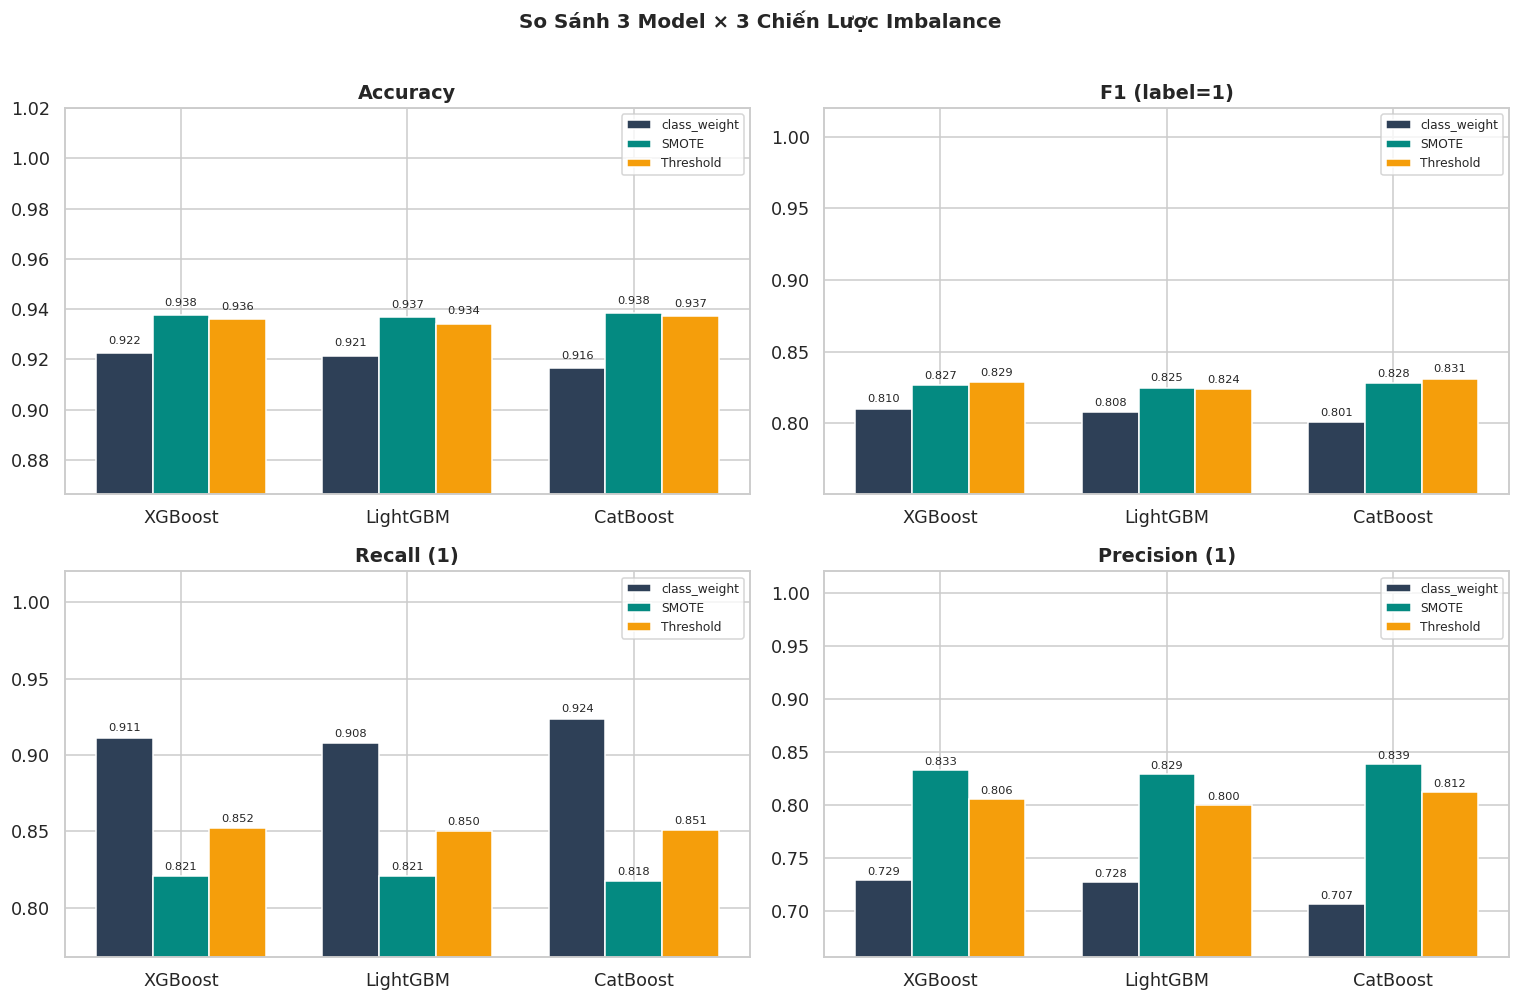

In [98]:
models_order   = ['XGBoost', 'LightGBM', 'CatBoost']
strategy_order = ['class_weight / is_unbalance', 'SMOTE', 'Threshold']

# Map tên rút gọn
def short_name(s):
    if 'XGBoost' in s:
        base = 'XGBoost'
    elif 'LightGBM' in s:
        base = 'LightGBM'
    else:
        base = 'CatBoost'
    if 'SMOTE' in s:       strat = 'SMOTE'
    elif 'Threshold' in s: strat = 'Threshold'
    else:                  strat = 'class_weight'
    return base, strat

plot_df = df_res[~df_res['Model'].str.contains('Baseline')].copy()
plot_df[['Base','Strategy']] = plot_df['Model'].apply(lambda x: pd.Series(short_name(x)))

metrics = ['Accuracy', 'F1 (label=1)', 'Recall (1)', 'Precision (1)']
strat_colors = {'class_weight': '#2E4057', 'SMOTE': '#048A81', 'Threshold': '#F59E0B'}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    x = np.arange(len(models_order))
    width = 0.25
    for i, (strat, color) in enumerate(strat_colors.items()):
        vals = []
        for base in models_order:
            row = plot_df[(plot_df['Base']==base) & (plot_df['Strategy']==strat)]
            vals.append(row[metric].values[0] if len(row) else 0)
        bars = ax.bar(x + i*width - width, vals, width,
                      label=strat, color=color, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(models_order)
    ax.set_ylim(max(0, plot_df[metric].min() - 0.05), 1.02)
    ax.set_title(metric, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('So Sánh 3 Model × 3 Chiến Lược Imbalance', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

###6.4. ROC Curve – tất cả model

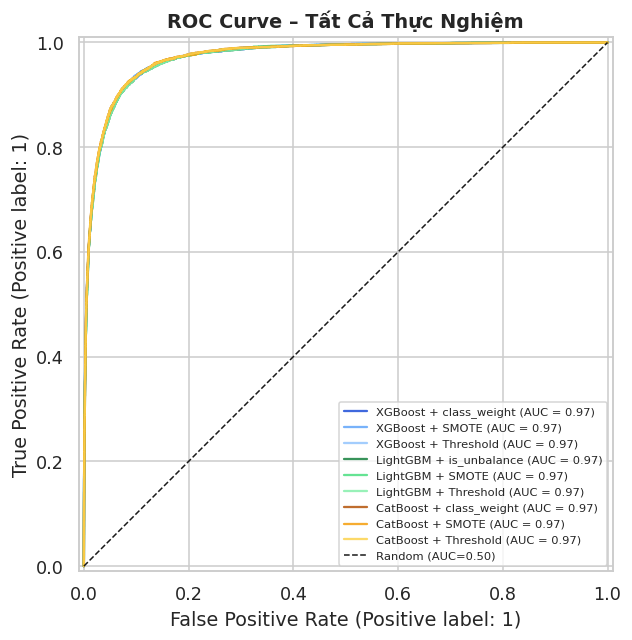

In [99]:
fig, ax = plt.subplots(figsize=(8, 6))

palette = {
    'XGBoost + class_weight' : '#1d4ed8',
    'XGBoost + SMOTE'        : '#60a5fa',
    'XGBoost + Threshold'    : '#93c5fd',
    'LightGBM + is_unbalance': '#15803d',
    'LightGBM + SMOTE'       : '#4ade80',
    'LightGBM + Threshold'   : '#86efac',
    'CatBoost + class_weight': '#b45309',
    'CatBoost + SMOTE'       : '#f59e0b',
    'CatBoost + Threshold'   : '#fcd34d',
}
model_map = {
    'XGBoost + class_weight' : xgb_cw, 'XGBoost + SMOTE'        : xgb_sm,
    'XGBoost + Threshold'    : xgb_th, 'LightGBM + is_unbalance' : lgb_cw,
    'LightGBM + SMOTE'       : lgb_sm, 'LightGBM + Threshold'    : lgb_th,
    'CatBoost + class_weight': cat_cw, 'CatBoost + SMOTE'        : cat_sm,
    'CatBoost + Threshold'   : cat_th,
}
for name, model in model_map.items():
    RocCurveDisplay.from_estimator(model, X_test_sel, y_test,
                                   name=name, ax=ax, color=palette[name], alpha=0.85)

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.50)')
ax.set_title('ROC Curve – Tất Cả Thực Nghiệm', fontweight='bold')
ax.legend(loc='lower right', fontsize=7.5)
plt.tight_layout(); plt.show()

## 6.5 Precision-Recall Curve

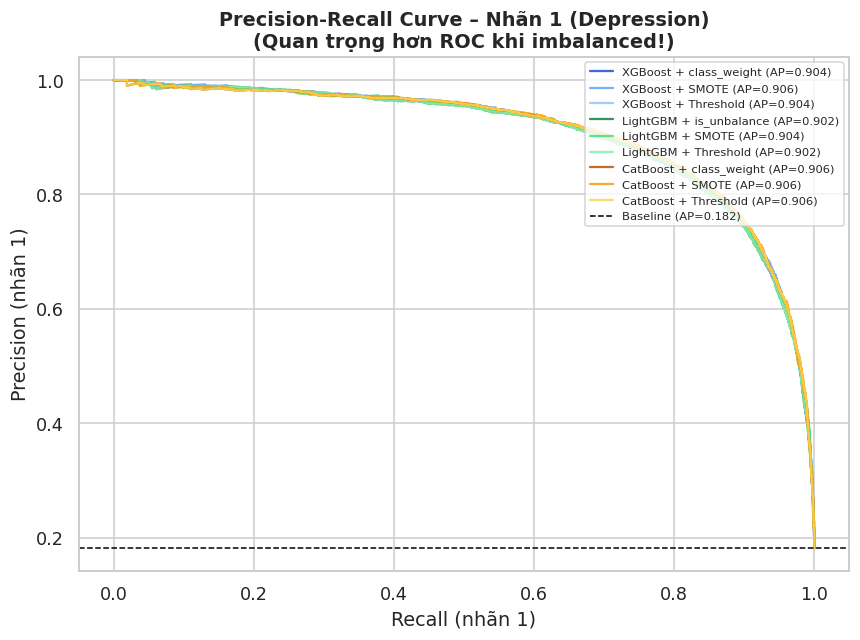

In [100]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in model_map.items():
    prob = model.predict_proba(X_test_sel)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})',
            color=palette[name], alpha=0.85)

# Baseline (random)
baseline_ap = y_test.mean()
ax.axhline(baseline_ap, color='black', linestyle='--', linewidth=1,
           label=f'Baseline (AP={baseline_ap:.3f})')

ax.set_xlabel('Recall (nhãn 1)')
ax.set_ylabel('Precision (nhãn 1)')
ax.set_title('Precision-Recall Curve – Nhãn 1 (Depression)\n(Quan trọng hơn ROC khi imbalanced!)', fontweight='bold')
ax.legend(loc='upper right', fontsize=7.5)
plt.tight_layout(); plt.show()

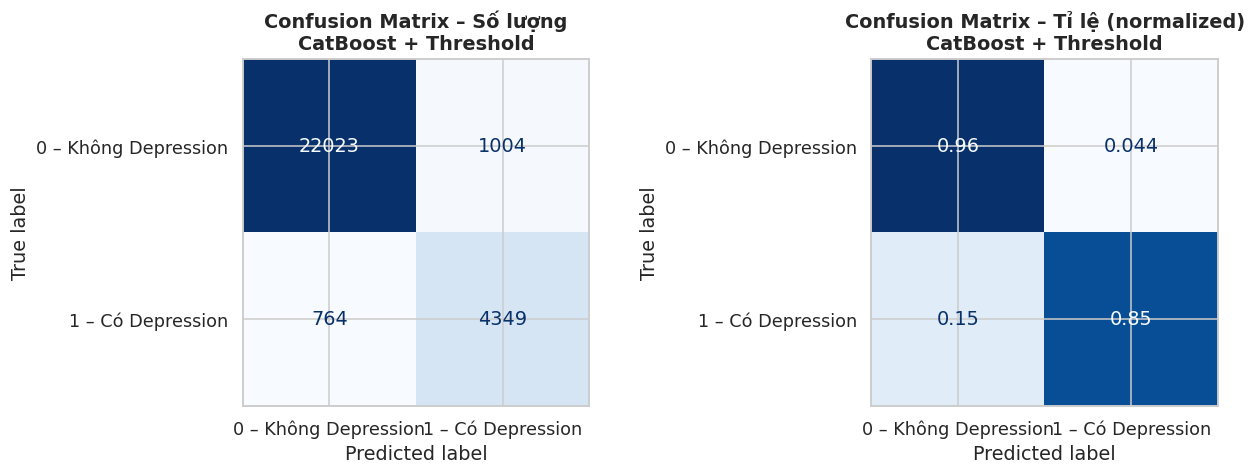


Mô hình tốt nhất: CatBoost + Threshold
   Threshold sử dụng : 0.74

📋 Classification Report:
                      precision    recall  f1-score   support

0 – Không Depression       0.97      0.96      0.96     23027
   1 – Có Depression       0.81      0.85      0.83      5113

            accuracy                           0.94     28140
           macro avg       0.89      0.90      0.90     28140
        weighted avg       0.94      0.94      0.94     28140



In [101]:
# ── 7.6 Confusion Matrix – mô hình tốt nhất (theo F1 label=1) ────────────────
best_row = df_res[~df_res['Model'].str.contains('Baseline')].sort_values(
    'F1 (label=1)', ascending=False
).iloc[0]

BEST_NAME  = best_row['Model']
BEST_THRESHOLD = best_row['Threshold']
BEST_MODEL = model_map.get(BEST_NAME.replace('', ''), lgb_th)

y_prob_best = BEST_MODEL.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= BEST_THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (norm, title) in zip(axes, [(None, 'Số lượng'), ('true', 'Tỉ lệ (normalized)')]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_best,
        display_labels=['0 – Không Depression', '1 – Có Depression'],
        normalize=norm, colorbar=False, ax=ax, cmap='Blues'
    )
    ax.set_title(f'Confusion Matrix – {title}\n{BEST_NAME}', fontweight='bold')

plt.tight_layout(); plt.show()

print(f'\nMô hình tốt nhất: {BEST_NAME}')
print(f'   Threshold sử dụng : {BEST_THRESHOLD:.2f}')
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_best,
      target_names=['0 – Không Depression','1 – Có Depression']))

##6.7. Feature Importance

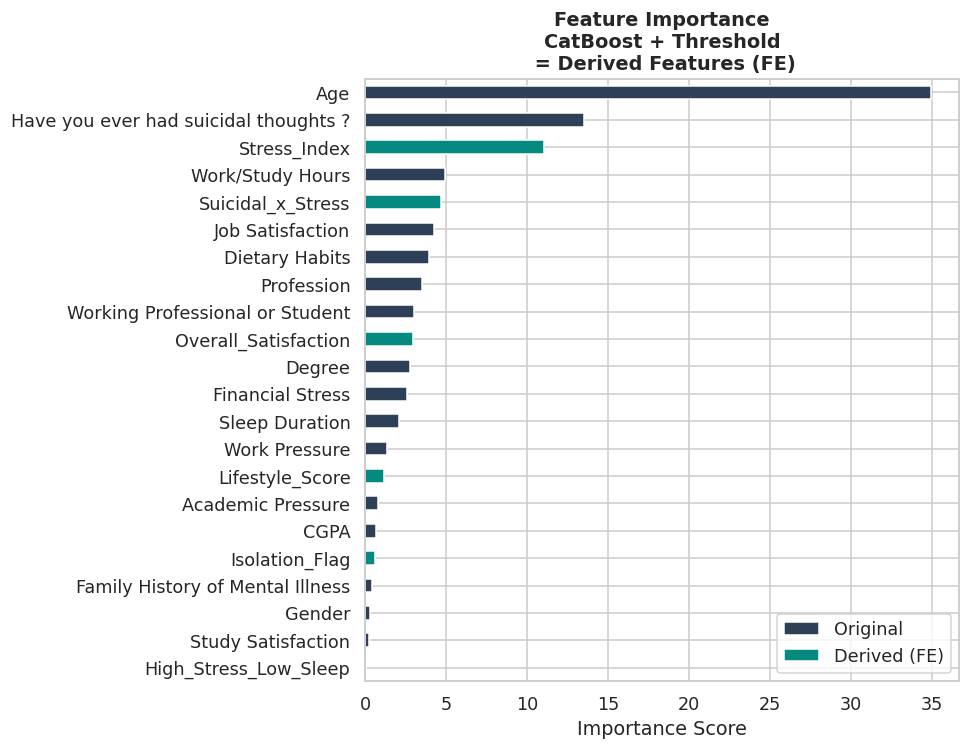

In [102]:
try:
    # LightGBM / XGBoost
    imp = pd.Series(BEST_MODEL.feature_importances_, index=X_train_sel.columns)
except:
    # CatBoost
    imp = pd.Series(BEST_MODEL.get_feature_importance(), index=X_train_sel.columns)

imp = imp.sort_values(ascending=True)

DERIVED = {'Stress_Index','Lifestyle_Score','Overall_Satisfaction',
           'High_Stress_Low_Sleep','Isolation_Flag','Suicidal_x_Stress'}
bar_colors = ['#048A81' if f in DERIVED else '#2E4057' for f in imp.index]

fig, ax = plt.subplots(figsize=(9, 7))
imp.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.set_title(f'Feature Importance\n{BEST_NAME}\n = Derived Features (FE)', fontweight='bold')
ax.set_xlabel('Importance Score')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#2E4057', label='Original'),
                   Patch(facecolor='#048A81', label='Derived (FE)')],
          loc='lower right')
plt.tight_layout(); plt.show()

##6.8. Bảng tổng kết

In [103]:
# ──  Bảng tổng kết cuối cùng ──────────────────────────────────────────────
final_cols = ['Model','Accuracy','AUC-ROC','F1 (label=1)','Precision (1)','Recall (1)','Threshold']
final_df   = df_res[final_cols].sort_values('F1 (label=1)', ascending=False)

print('='*90)
print('  BẢNG KẾT QUẢ CUỐI CÙNG – SẮP XẾP THEO F1 NHÃN 1')
print('='*90)
print(final_df.to_string(index=False))
print('='*90)

  BẢNG KẾT QUẢ CUỐI CÙNG – SẮP XẾP THEO F1 NHÃN 1
                  Model  Accuracy  AUC-ROC  F1 (label=1)  Precision (1)  Recall (1)  Threshold
   CatBoost + Threshold    0.9372   0.9739        0.8311         0.8124      0.8506       0.74
    XGBoost + Threshold    0.9359   0.9732        0.8285         0.8061      0.8521       0.72
       CatBoost + SMOTE    0.9383   0.9739        0.8280         0.8387      0.8175       0.50
        XGBoost + SMOTE    0.9375   0.9738        0.8267         0.8329      0.8207       0.50
       LightGBM + SMOTE    0.9367   0.9733        0.8249         0.8292      0.8207       0.50
   LightGBM + Threshold    0.9341   0.9726        0.8241         0.7998      0.8500       0.70
 XGBoost + class_weight    0.9224   0.9732        0.8102         0.7293      0.9112       0.50
LightGBM + is_unbalance    0.9215   0.9726        0.8077         0.7275      0.9077       0.50
CatBoost + class_weight    0.9164   0.9739        0.8006         0.7065      0.9237       0.50
